# Laboratorio 3: EDP con el método de diferencias finitas

**Andrés Felipe Serrano Barrios**

Física Computacional I (0302151), grupo 001

Instituto de Física, Universidad de Antioquia

Semestre 2026-2, profesor Andrés Felipe Rivera Romero

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False})

---

# Ejercicio 1. Caja cuadrada con Jacobi y tolerancia

$$\nabla^2 u = 0,\qquad 0\leq x\leq L,\quad 0\leq y\leq L,$$

$$u(x,0)=V_0=100\ \text{V},\qquad u(0,y)=u(L,y)=u(x,L)=0,$$

con $L=N\Delta=100$ y $\Delta=1$. El arreglo guarda $u_{i,j}=u(x_i,y_j)$, primer índice sobre $x$.

## 1.1 La estrategia

Sumando los desarrollos de Taylor de $u$ a izquierda y derecha de un nodo, los términos impares se
cancelan y la segunda derivada queda $(u_{i+1,j}-2u_{i,j}+u_{i-1,j})/\Delta^2+\mathcal{O}(\Delta^2)$.
Haciendo lo mismo en $y$ y sustituyendo en $\nabla^2u=0$, el paso se cancela y Laplace se vuelve una
**propiedad de promedio**:

$$\boxed{\;u_{i,j}=\tfrac14\left[u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}\right]\;}$$

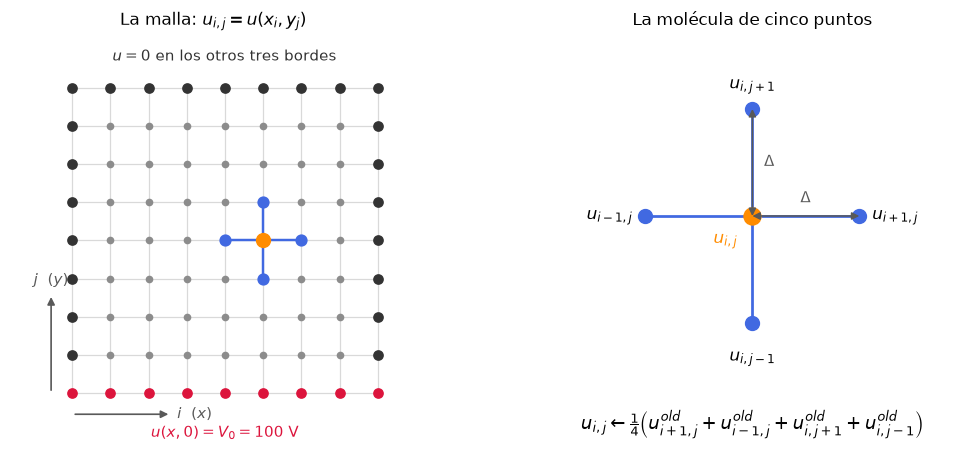

Eso no da $u_{i,j}$ de forma explícita, porque los vecinos tampoco se conocen: son $(N-1)^2=9801$
incógnitas acopladas. En vez de invertir la matriz se **relaja**, repitiendo el promedio hasta que la
malla deje de moverse. Lo propio de **Jacobi** es la copia: si el barrido leyera del mismo arreglo que
escribe, los nodos ya visitados entrarían con su valor nuevo y el método sería Gauss-Seidel.

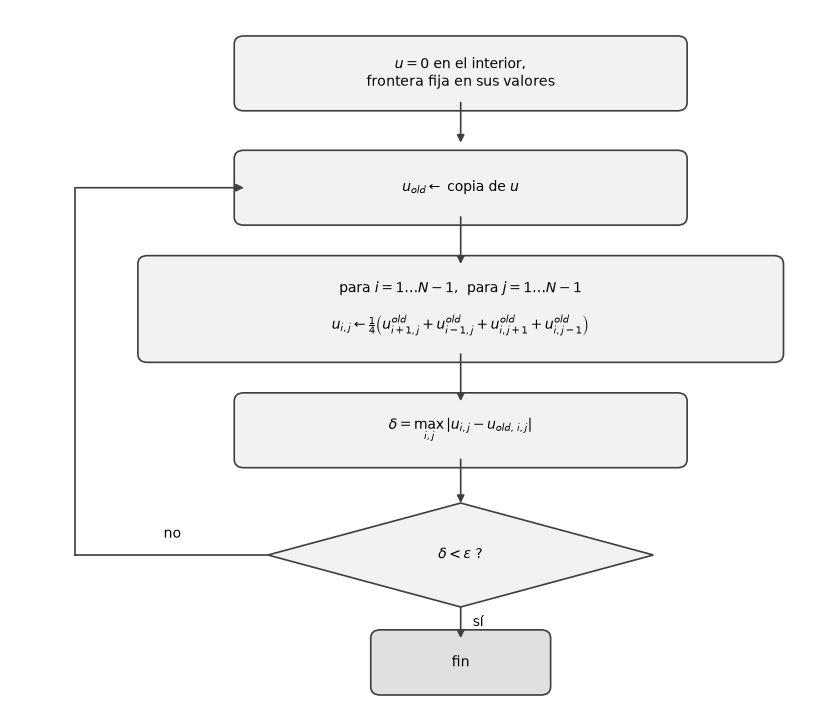

In [2]:
V0 = 100.0
L = 100.0
dx = 1.0
N = int(L/dx)

x = np.linspace(0.0, L, N+1)
y = np.linspace(0.0, L, N+1)


def malla_inicial(n_lado, potencial):
    """Malla con u(x,0)=potencial y los otros tres bordes de Dirichlet en cero."""
    malla = np.zeros((n_lado+1, n_lado+1))
    for i in range(1, n_lado):
        malla[i, 0] = potencial
    return malla


def barrido_jacobi(u, u_viejo, n_lado):
    """Un barrido de Jacobi: los vecinos se leen de u_viejo y el resultado se escribe en u."""
    mayor = 0.0
    for i in range(1, n_lado):
        for j in range(1, n_lado):
            promedio = 0.25*(u_viejo[i+1, j] + u_viejo[i-1, j] + u_viejo[i, j+1] + u_viejo[i, j-1])
            cambio = abs(promedio - u_viejo[i, j])
            if cambio > mayor:
                mayor = cambio
            u[i, j] = promedio
    return mayor


def relajacion_jacobi(malla, epsilon, umbrales=None, max_barridos=100000):
    """Relajacion de Jacobi. Guarda una copia del campo al cruzar por primera vez cada umbral."""
    u = malla.copy()
    n_lado = malla.shape[0] - 1
    historial = []
    pendientes = sorted(umbrales, reverse=True) if umbrales else []
    copias = {}

    for _ in range(max_barridos):
        u_viejo = u.copy()
        cambio = barrido_jacobi(u, u_viejo, n_lado)
        historial.append(cambio)
        while pendientes and cambio < pendientes[0]:
            copias[pendientes.pop(0)] = (u.copy(), len(historial))
        if cambio < epsilon:
            break

    return u, historial, copias

Las esquinas $(0,0)$ y $(L,0)$ se dejan en $0$ y no en $V_0$: ahí el dato es discontinuo y el valor es
ambiguo. No entran en la fórmula del promedio, así que solo afectan al dibujo.

In [3]:
inicio = time.process_time()
u_tol3, hist_tol3, _ = relajacion_jacobi(malla_inicial(N, V0), epsilon=1e-3)

print(f"epsilon = 1e-3 -> {len(hist_tol3)} barridos, {time.process_time() - inicio:.1f} s")
print(f"u(L/2, L/2) = {u_tol3[N//2, N//2]:.4f} V   (valor exacto: 25)")

epsilon = 1e-3 -> 6073 barridos, 45.1 s
u(L/2, L/2) = 22.9773 V   (valor exacto: 25)


El centro es un control exacto: si los cuatro bordes valieran $V_0$ la solución sería $u\equiv V_0$, y
como solo uno lo vale, el promedio obliga a $u(L/2,L/2)=V_0/4=25$ V.

## 1.2 El campo para $\varepsilon=10^{-3}$

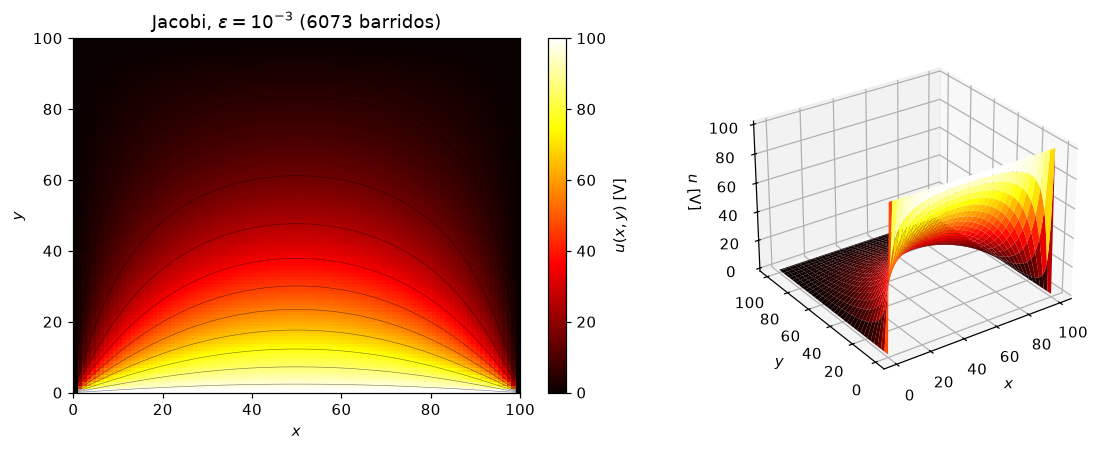

In [4]:
def graficar_campo(campo, eje_x, eje_y, titulo, cmap="hot"):
    """Mapa y superficie 3D de un campo guardado como u[i,j] = u(x_i, y_j)."""
    fig = plt.figure(figsize=(11, 4.2))

    ax = fig.add_subplot(1, 2, 1)
    im = ax.imshow(campo.T, origin="lower", extent=[eje_x[0], eje_x[-1], eje_y[0], eje_y[-1]],
                   cmap=cmap, aspect="auto")
    ax.contour(eje_x, eje_y, campo.T, levels=np.linspace(5, 95, 10), colors="k",
               linewidths=0.4, alpha=0.5)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_title(titulo)
    fig.colorbar(im, ax=ax, label="$u(x,y)$ [V]")

    ax3 = fig.add_subplot(1, 2, 2, projection="3d")
    malla_x, malla_y = np.meshgrid(eje_x, eje_y, indexing="ij")
    ax3.plot_surface(malla_x, malla_y, campo, cmap=cmap, linewidth=0, antialiased=True)
    ax3.set_xlabel("$x$")
    ax3.set_ylabel("$y$")
    ax3.set_zlabel("$u$ [V]")
    ax3.view_init(elev=28, azim=-125)

    fig.tight_layout()
    return fig


graficar_campo(u_tol3, x, y, f"Jacobi, $\\varepsilon=10^{{-3}}$ ({len(hist_tol3)} barridos)")
plt.show()

El potencial cae de $100$ V en el borde inferior a $0$ en los otros tres, sin extremos interiores, y
todo el gradiente se concentra en las dos esquinas discontinuas.

## 1.3 Las demás tolerancias

El enunciado admite cualquier valor en $10^{-6}<\varepsilon<10^{-1}$. Como el incremento
$\delta^{(k)}$ decrece de forma monótona, no hace falta relanzar seis veces: basta una corrida hasta
$10^{-6}$ copiando el campo cada vez que se cruza un umbral.

In [5]:
umbrales = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

inicio = time.process_time()
u_referencia, historial_ref, copias = relajacion_jacobi(malla_inicial(N, V0), epsilon=1e-6, umbrales=umbrales)
print(f"{len(historial_ref)} barridos en {time.process_time() - inicio:.1f} s")

filas = []
for tolerancia in umbrales:
    campo, barridos = copias[tolerancia]
    centro = campo[N//2, N//2]
    filas.append({
        "tolerancia": tolerancia,
        "barridos": barridos,
        "u(L/2, L/2) [V]": centro,
        "error en el centro [V]": abs(centro - 25.0),
        "error / tolerancia": abs(centro - 25.0)/tolerancia,
    })

tabla = pd.DataFrame(filas)
tabla.style.format({
    "tolerancia": "{:.0e}",
    "u(L/2, L/2) [V]": "{:.5f}",
    "error en el centro [V]": "{:.3e}",
    "error / tolerancia": "{:.0f}",
}).hide(axis="index")

20066 barridos en 150.5 s


tolerancia,barridos,"u(L/2, L/2) [V]",error en el centro [V],error / tolerancia
1e-01,243,0.00054,2.500e+01,250
1e-02,1909,9.44737,1.555e+01,1555
1e-03,6073,22.97729,2.023e+00,2023
1e-04,10736,24.79750,2.025e-01,2025
1e-05,15402,24.97976,2.024e-02,2024
1e-06,20066,24.99797,2.025e-03,2025


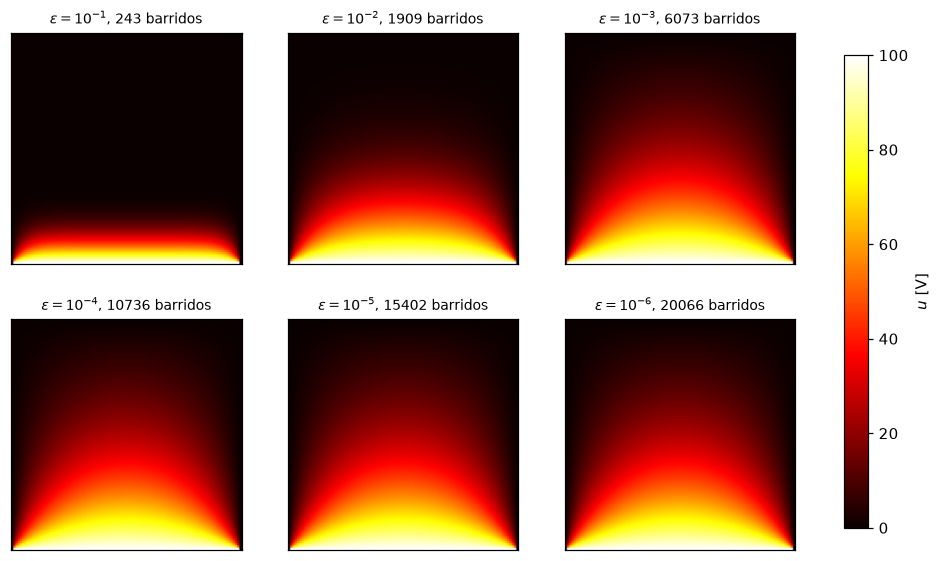

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.2))

for eje_plot, tolerancia in zip(axes.flat, umbrales):
    campo, barridos = copias[tolerancia]
    imagen = eje_plot.imshow(campo.T, origin="lower", extent=[0, L, 0, L],
                             cmap="hot", vmin=0.0, vmax=V0)
    exponente = int(round(np.log10(tolerancia)))
    eje_plot.set_title(rf"$\varepsilon=10^{{{exponente}}}$, {barridos} barridos", fontsize=9)
    eje_plot.set_xticks([])
    eje_plot.set_yticks([])

fig.colorbar(imagen, ax=axes, label="$u$ [V]", shrink=0.9)
plt.show()

Con $\varepsilon=10^{-1}$ la relajación se detiene cuando el calor del borde inferior apenas ha
entrado unos nodos y el resto de la caja sigue casi en la conjetura inicial $u=0$.

La última columna de la tabla es el punto fino: **lo que se mide es cuánto se movió la solución, no
cuánto le falta.** El error $e^{(k)}$ cumple la misma recursión que $u$, y sus modos propios
$\sin(p\pi i/N)\sin(q\pi j/N)$ se multiplican cada barrido por
$\lambda_{p,q}=\frac12[\cos(p\pi/N)+\cos(q\pi/N)]$. El más lento es $p=q=1$, así que
$\rho=\cos(\pi/N)\approx0.99951$ y sumando la cola geométrica que falta por recorrer

$$\|u^{(k)}-u^{\text{exacta}}\|\approx\frac{\delta^{(k)}}{1-\rho}\approx2\times10^{3}\,\delta^{(k)},$$

que es el factor constante que sale medido en las cuatro últimas filas. Por eso con
$\varepsilon=10^{-3}$ el centro todavía marca $22.98$ V y no $25$.

rho teorico = 0.999507   rho medido = 0.999507
1/(1 - rho) = 2027


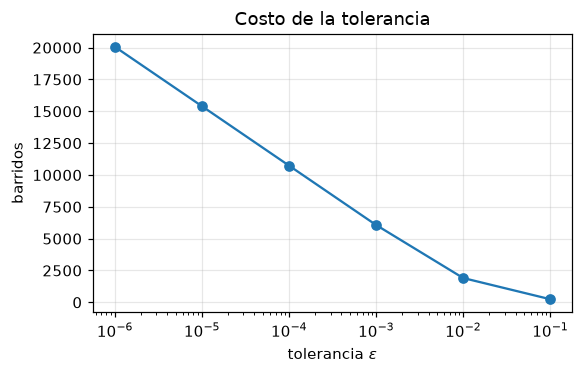

In [7]:
rho_teorico = np.cos(np.pi/N)
cola = np.array(historial_ref[len(historial_ref)//2:])
rho_medido = np.exp(np.polyfit(np.arange(len(cola)), np.log(cola), 1)[0])

print(f"rho teorico = {rho_teorico:.6f}   rho medido = {rho_medido:.6f}")
print(f"1/(1 - rho) = {1.0/(1.0 - rho_teorico):.0f}")

fig, ax = plt.subplots(figsize=(5.4, 3.5))
ax.semilogx(tabla["tolerancia"], tabla["barridos"], "o-")
ax.set_xlabel(r"tolerancia $\varepsilon$")
ax.set_ylabel("barridos")
ax.set_title("Costo de la tolerancia")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 1.4 Comparación con la serie de Fourier

Separando $u=X(x)Y(y)$ queda $X''/X=-Y''/Y=-k^2$. Las condiciones $u(0,y)=u(L,y)=0$ cuantizan la
constante de separación, $X_n=\sin(n\pi x/L)$ con $k_n=n\pi/L$, y la combinación de $\sinh$ que ya
cumple $u(x,L)=0$ es $Y_n=\sinh[n\pi(L-y)/L]$. Proyectando la última condición sobre la base de senos,
los coeficientes pares se anulan y queda

$$\boxed{\;u(x,y)=\sum_{n\ \text{impar}}\frac{4V_0}{n\pi}\sin\frac{n\pi x}{L}
\frac{\sinh[n\pi(L-y)/L]}{\sinh(n\pi)}\;}$$

Evaluado así desborda, porque $\sinh(n\pi)$ pasa de $10^{308}$ hacia $n\approx226$ y van a hacer falta
cientos de términos. La forma estable es

$$\frac{\sinh a}{\sinh b}=e^{a-b}\frac{1-e^{-2a}}{1-e^{-2b}},\qquad a=\frac{n\pi(L-y)}{L},\quad b=n\pi,$$

con $a-b=-n\pi y/L\leq0$. Escrita así se lee de una el tamaño del término,
$|u_n|\sim(4V_0/n\pi)e^{-n\pi y/L}$, que decide el apartado siguiente.

In [8]:
def termino_fourier(malla_x, malla_y, longitud, potencial, modo):
    """Un modo impar de la serie, escrito en la forma que no desborda."""
    arg_arriba = modo*np.pi*(longitud - malla_y)/longitud
    arg_total = modo*np.pi
    razon = np.exp(arg_arriba - arg_total)*(1.0 - np.exp(-2.0*arg_arriba))/(1.0 - np.exp(-2.0*arg_total))
    return (4.0*potencial/(modo*np.pi))*np.sin(modo*np.pi*malla_x/longitud)*razon


def serie_fourier(eje_x, eje_y, longitud, potencial, n_modos):
    """Serie truncada a n_modos modos impares."""
    malla_x, malla_y = np.meshgrid(eje_x, eje_y, indexing="ij")
    suma = np.zeros_like(malla_x)
    for modo in range(1, 2*n_modos, 2):
        suma = suma + termino_fourier(malla_x, malla_y, longitud, potencial, modo)
    return suma


u_fourier = serie_fourier(x, y, L, V0, 4000)
print(f"u(L/2, L/2) por Fourier = {u_fourier[N//2, N//2]:.10f} V")

u(L/2, L/2) por Fourier = 25.0000000000 V


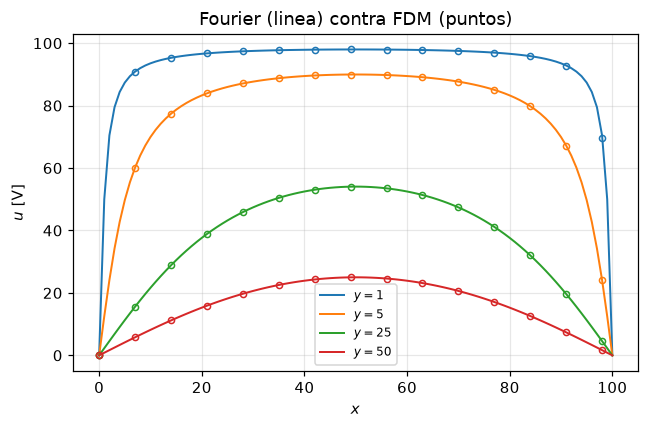

diferencia maxima en y >=  1: 7.180e-01 V
diferencia maxima en y >= 10: 4.505e-02 V


In [9]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))

for nivel in [1, 5, 25, 50]:
    trazo = ax.plot(x, u_fourier[:, nivel], lw=1.3, label=f"$y={y[nivel]:.0f}$")[0]
    x_puntos = []
    u_puntos = []
    for i in range(0, N+1, 7):
        x_puntos.append(x[i])
        u_puntos.append(u_referencia[i, nivel])
    ax.plot(x_puntos, u_puntos, "o", ms=4, mfc="none", color=trazo.get_color())
ax.set_xlabel("$x$")
ax.set_ylabel("$u$ [V]")
ax.set_title("Fourier (linea) contra FDM (puntos)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

diferencia = np.abs(u_referencia - u_fourier)
for profundidad in [1, 10]:
    maximo_columna = 0.0
    for columna in range(profundidad, N+1):
        maximo_columna = max(maximo_columna, diferencia[:, columna].max())
    print(f"diferencia maxima en y >= {profundidad:2d}: {maximo_columna:.3e} V")

Los perfiles se superponen a simple vista. La diferencia solo pesa en las primeras filas, junto a las
esquinas discontinuas, y cae dos órdenes de magnitud al entrar en la caja.

## 1.5 Cuántos términos para $\varepsilon=10^{-4}$

Depende de dónde se mire. En $y=0$ el amortiguamiento exponencial desaparece y solo queda el
decaimiento $1/n$: la serie es la de una onda cuadrada y sufre **Gibbs** junto a las esquinas. Para
$y>0$ la exponencial manda y bastan pocos términos. Se toma como referencia la serie con 4000 modos.

In [10]:
def error_por_truncamiento(eje_x, eje_y, longitud, potencial, max_modos, referencia, filas):
    """Maximo de |suma parcial - referencia| al anadir cada modo, en todo el dominio y en filas de y elegidas."""
    malla_x, malla_y = np.meshgrid(eje_x, eje_y, indexing="ij")
    suma = np.zeros_like(malla_x)
    todo_el_dominio = []
    interior = []
    por_fila = []

    for modo in range(1, 2*max_modos, 2):
        suma = suma + termino_fourier(malla_x, malla_y, longitud, potencial, modo)
        separacion = np.abs(suma - referencia)
        todo_el_dominio.append(separacion.max())
        deepest = 0.0
        for columna in range(1, separacion.shape[1]):
            deepest = max(deepest, separacion[:, columna].max())
        interior.append(deepest)
        por_fila.append([separacion[:, fila].max() for fila in filas])

    return np.array(todo_el_dominio), np.array(interior), np.array(por_fila)


filas_prueba = [1, 2, 5, 10, 25, 50]
err_total, err_interior, err_filas = error_por_truncamiento(x, y, L, V0, 400, u_fourier, filas_prueba)

necesarios = []
for columna, fila in enumerate(filas_prueba):
    primero = int(np.argmax(err_filas[:, columna] < 1e-4)) + 1
    necesarios.append({"y": y[fila], "modos impares M": primero, "n maximo": 2*primero - 1})

print(f"para toda la malla con y >= 1: M = {int(np.argmax(err_interior < 1e-4)) + 1} modos impares")
print(f"error minimo incluyendo y = 0: {err_total.min():.3f} V")
pd.DataFrame(necesarios).style.format({"y": "{:.0f}"}).hide(axis="index")

para toda la malla con y >= 1: M = 169 modos impares


error minimo incluyendo y = 0: 0.965 V


y,modos impares M,n maximo
1,169,337
2,85,169
5,35,69
10,18,35
25,7,13
50,4,7


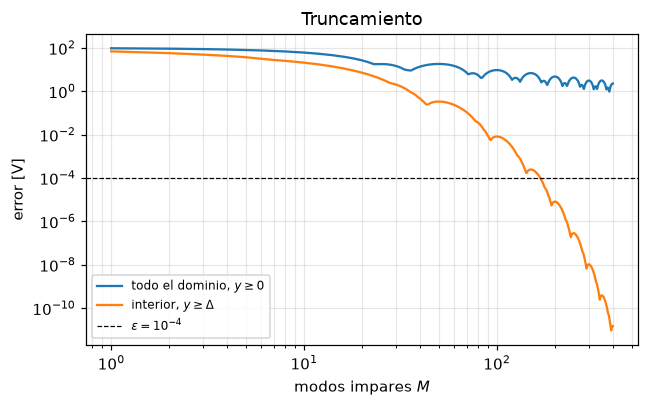

In [11]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))

modes = np.arange(1, len(err_interior)+1)
ax.loglog(modes, err_total, label=r"todo el dominio, $y\geq0$")
ax.loglog(modes, err_interior, label=r"interior, $y\geq\Delta$")
ax.axhline(1e-4, color="k", ls="--", lw=0.8, label=r"$\varepsilon=10^{-4}$")
ax.set_xlabel("modos impares $M$")
ax.set_ylabel("error [V]")
ax.set_title("Truncamiento")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()

**Respuesta.** Sobre los nodos con $y\geq\Delta=1$ hacen falta unos $169$ modos impares, es decir
términos hasta $n\approx337$. El producto $M\,y$ sale casi constante, $\approx170$, que es lo que
predice el término general: exigir $e^{-n\pi y/L}<\varepsilon$ da $n\gtrsim(L/\pi y)\ln(1/\varepsilon)$,
o sea $M\propto1/y$. En el plano medio bastan cuatro.

En $y=0$ **ninguna cantidad finita alcanza $10^{-4}$**: la curva se estanca cerca de un voltio y
decae solo como $1/M$. Por eso la comparación con diferencias finitas se hace en el interior.

## 1.6 Lo que cuestan los ciclos en Python

Rivera lo comentó en clase: al escribir el barrido con slicing, el recorrido lo hace numpy en código
C ya compilado y no Python nodo por nodo. El barrido de Jacobi se presta a comprobarlo, porque
escrito de las dos formas da el mismo campo pero no cuesta lo mismo.

In [12]:
def barrido_jacobi_con_slicing(u, u_viejo):
    """El mismo barrido, escrito con slicing para que el recorrido lo haga numpy."""
    u[1:-1, 1:-1] = 0.25*(u_viejo[2:, 1:-1] + u_viejo[:-2, 1:-1]
                          + u_viejo[1:-1, 2:] + u_viejo[1:-1, :-2])
    return np.abs(u[1:-1, 1:-1] - u_viejo[1:-1, 1:-1]).max()


con_ciclos = malla_inicial(N, V0)
con_slicing = malla_inicial(N, V0)
for _ in range(20):
    barrido_jacobi(con_ciclos, con_ciclos.copy(), N)
    barrido_jacobi_con_slicing(con_slicing, con_slicing.copy())
print(f"tras 20 barridos, diferencia entre los dos campos: "
      f"{np.abs(con_ciclos - con_slicing).max():.1e} V")

malla = malla_inicial(N, V0)
inicio = time.perf_counter()
for _ in range(20):
    barrido_jacobi(malla, malla.copy(), N)
costo_ciclos = (time.perf_counter() - inicio)/20

malla = malla_inicial(N, V0)
inicio = time.perf_counter()
for _ in range(2000):
    barrido_jacobi_con_slicing(malla, malla.copy())
costo_slicing = (time.perf_counter() - inicio)/2000

print(f"un barrido con ciclos for: {1000*costo_ciclos:8.3f} ms")
print(f"un barrido con slicing:   {1000*costo_slicing:8.3f} ms")
print(f"factor: {costo_ciclos/costo_slicing:.0f}x")

tras 20 barridos, diferencia entre los dos campos: 0.0e+00 V


un barrido con ciclos for:    7.209 ms
un barrido con slicing:      0.041 ms
factor: 176x


---

# Ejercicio 2 (bonus). Frontera abierta

Franja semiinfinita $0\leq x\leq L$, $0\leq y<\infty$, con

$$u(0,y)=u(L,y)=0,\qquad u(x,\infty)=0,\qquad u(x,0)=u_0\sin\frac{2\pi x}{L}.$$

El enunciado escribe el dato como $u_0\sin(2\pi x/L)e^{-2\pi y/L}$; en $y=0$, que es donde se impone,
se reduce a lo anterior.

## 2.1 Solución analítica

Igual que antes, $u=X(x)Y(y)$ y las condiciones laterales dan $X_n=\sin(n\pi x/L)$ con $k_n=n\pi/L$.
Lo que cambia es $Y$. Su solución general es

$$Y_n(y)=A_ne^{-k_ny}+B_ne^{+k_ny},$$

y aquí es donde el dominio abierto decide: en la caja cerrada ambas exponenciales sobrevivían y se
combinaban en el $\sinh$ que se anula en $y=L$, mientras que $u(x,\infty)=0$ **mata la creciente**,
$B_n=0$. Queda

$$u(x,y)=\sum_n b_n\sin\frac{n\pi x}{L}e^{-n\pi y/L},$$

con cada armónico apagándose con su propia longitud de penetración $\ell_n=L/n\pi$. Imponiendo $y=0$,
el dato ya **es** un elemento de la base, así que $b_n=u_0\delta_{n,2}$ sin integral que calcular y la
suma tiene un solo término:

$$\boxed{\;u(x,y)=u_0\sin\frac{2\pi x}{L}\,e^{-2\pi y/L}\;}$$

Se comprueba de una: $\partial_x^2u=-(2\pi/L)^2u$ y $\partial_y^2u=+(2\pi/L)^2u$ suman cero.

## 2.2 Solución numérica

Una malla no llega a $y=\infty$, así que hay que truncar en $y_{\max}$ e inventar allí una condición.
Poner $u=0$ es falso, porque el campo todavía vale $u_0e^{-2\pi y_{\max}/L}$, y obliga a alejar mucho
la frontera. En vez del valor se impone el comportamiento conocido, $\partial_yu=-ku$ con $k=2\pi/L$,
atando la última fila a la penúltima, $u(x,y_{\max})=u(x,y_{\max}-\Delta)e^{-k\Delta}$: es una
condición de **Robin** que deja salir la solución en vez de reflejarla, y con ella basta
$y_{\max}=L/2$.

La relajación se hace aquí con **sobrerrelajación sucesiva**, que es Gauss-Seidel exagerando cada
corrección con un factor $\omega\in(1,2)$; con $\omega_{\text{opt}}=2/[1+\sin(\pi/N)]$ baja de
$\mathcal{O}(N^2)$ barridos a $\mathcal{O}(N)$. El enunciado solo fija Jacobi para el ejercicio 1.

In [13]:
def barrido_relajacion(u, n_filas, n_columnas, omega, fijo):
    """Un barrido de Gauss-Seidel (omega=1) o SOR sobre el mismo arreglo, saltando los nodos fijos."""
    mayor = 0.0
    for i in range(1, n_filas):
        for j in range(1, n_columnas):
            if fijo[i, j]:
                continue
            promedio = 0.25*(u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1])
            cambio = omega*(promedio - u[i, j])
            u[i, j] = u[i, j] + cambio
            if abs(cambio) > mayor:
                mayor = abs(cambio)
    return mayor


def relajacion(malla, epsilon, omega, fijo=None, decaimiento_arriba=None, max_barridos=100000):
    """Relajacion de Gauss-Seidel o SOR, con nodos interiores fijos y fila superior amortiguada opcionales."""
    u = malla.copy()
    n_filas = u.shape[0] - 1
    n_columnas = u.shape[1] - 1
    fijo = np.zeros(u.shape, dtype=bool) if fijo is None else fijo

    for iteration in range(1, max_barridos+1):
        cambio = barrido_relajacion(u, n_filas, n_columnas, omega, fijo)
        if decaimiento_arriba is not None:
            for i in range(u.shape[0]):
                u[i, n_columnas] = u[i, n_columnas-1]*decaimiento_arriba
        if cambio < epsilon:
            return u, iteration

    return u, max_barridos

In [14]:
u0 = 100.0
k_decaimiento = 2.0*np.pi/L


def franja_truncada(y_max, paso):
    """Franja truncada con el dato sin(2 pi x / L) en y = 0."""
    n_x = int(round(L/paso))
    n_y = int(round(y_max/paso))
    eje_x = np.arange(n_x+1)*paso
    eje_y = np.arange(n_y+1)*paso

    malla = np.zeros((n_x+1, n_y+1))
    for i in range(n_x+1):
        malla[i, 0] = u0*np.sin(2.0*np.pi*eje_x[i]/L)

    return malla, eje_x, eje_y


def franja_analitica(eje_x, eje_y):
    """Forma cerrada u = u0 sin(2 pi x / L) exp(-2 pi y / L)."""
    malla_x, malla_y = np.meshgrid(eje_x, eje_y, indexing="ij")
    return u0*np.sin(2.0*np.pi*malla_x/L)*np.exp(-k_decaimiento*malla_y)


def omega_rectangulo(n_x, n_y):
    """Parametro optimo de SOR para una malla rectangular, a partir del radio espectral de Jacobi."""
    radio_jacobi = 0.5*(np.cos(np.pi/n_x) + np.cos(np.pi/n_y))
    return 2.0/(1.0 + np.sqrt(1.0 - radio_jacobi**2))


def resolver_franja(y_max, paso=1.0, absorbente=False, epsilon=1e-9):
    """Resuelve la franja truncada y devuelve el campo, los ejes, el error maximo y los barridos."""
    malla, eje_x, eje_y = franja_truncada(y_max, paso)
    decaimiento = np.exp(-k_decaimiento*paso) if absorbente else None
    campo, barridos = relajacion(malla, epsilon, omega_rectangulo(len(eje_x)-1, len(eje_y)-1), decaimiento_arriba=decaimiento)
    return campo, eje_x, eje_y, np.abs(campo - franja_analitica(eje_x, eje_y)).max(), barridos


u_franja, eje_x_franja, eje_y_franja, err_franja, barridos_franja = resolver_franja(50.0, absorbente=True)
u_franja_exacta = franja_analitica(eje_x_franja, eje_y_franja)

print(f"malla {u_franja.shape[0]} x {u_franja.shape[1]}, {barridos_franja} barridos")
print(f"diferencia maxima contra la solucion analitica: {err_franja:.3e} V")

malla 101 x 51, 507 barridos
diferencia maxima contra la solucion analitica: 1.202e-02 V


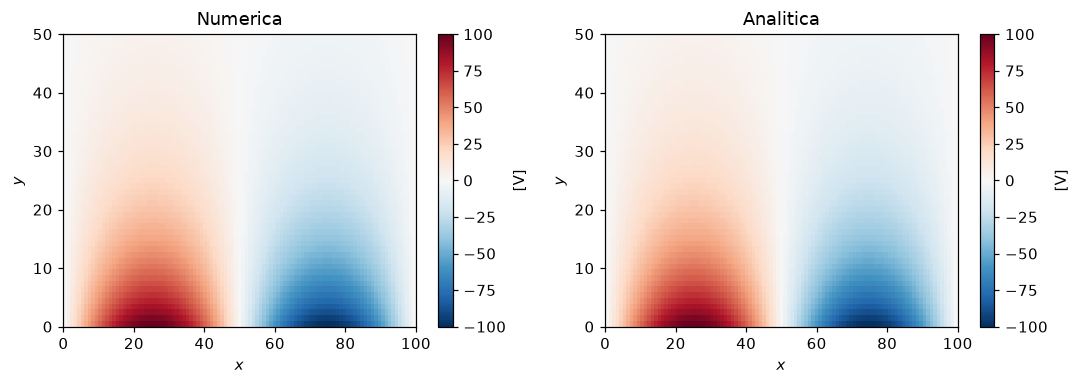

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

for eje_plot, campo, titulo in zip(axes, [u_franja, u_franja_exacta], ["Numerica", "Analitica"]):
    imagen = eje_plot.imshow(campo.T, origin="lower", extent=[0, L, 0, eje_y_franja[-1]],
                             aspect="auto", cmap="RdBu_r", vmin=-u0, vmax=u0)
    eje_plot.set_xlabel("$x$")
    eje_plot.set_ylabel("$y$")
    eje_plot.set_title(titulo)
    fig.colorbar(imagen, ax=eje_plot, label="[V]")

fig.tight_layout()
plt.show()

Las dos son el mismo campo: el dato era un único modo propio, así que los perfiles horizontales
conservan la forma del seno y solo se reescalan con la profundidad. Lo que queda de diferencia,
$1.2\times10^{-2}$ V, es error de discretización: la malla apaga el modo con la tasa
$\cosh(\beta\Delta)=2-\cos(k\Delta)$, un poco más despacio que la $k$ continua.

---

# Ejercicio 3. Condensador de placas paralelas

Alrededor de las placas no hay carga libre, así que $\nabla^2\phi=0$ y sirve el mismo relajador. Lo
que cambia es dónde están las condiciones de Dirichlet: ya no solo en el borde del dominio, sino
también en los nodos interiores que ocupan los conductores.

Cada placa infinita con densidad $\sigma$ da $|\vec{E}|=\sigma/2\epsilon_0$ hacia afuera de sus dos
caras. Con dos placas de carga opuesta, entre ellas los campos se suman y afuera se cancelan:

$$|\vec{E}|\approx\frac{\sigma}{\epsilon_0}\ \text{dentro},\qquad|\vec{E}|\approx0\ \text{fuera},$$

lo que en términos del voltaje aplicado es $|\vec{E}|=\Delta V/d=100/10=10$ V/m.

**Geometría**, la de la figura del enunciado: dos placas **verticales**, de longitud $\ell=20$ en $y$,
separadas $d=10$ en $x$, de un nodo de espesor, la izquierda a $+50$ V y la derecha a $-50$ V,
centradas en una caja $100\times100$ aterrizada con $\Delta=1$. Los nodos de las placas se marcan en
una máscara y el relajador los salta, que es la forma de imponer Dirichlet sobre una frontera interna
sin deformar la malla.

In [16]:
lado_caja = 100.0
largo_placa = 20.0
separacion_placas = 10.0
voltaje_placa = 50.0


def montar_condensador(lado=lado_caja, paso=1.0, longitud=largo_placa, separacion=separacion_placas,
                    voltaje=voltaje_placa):
    """Caja aterrizada con dos placas verticales separadas en x, fijadas a +-voltaje."""
    n_lado = int(round(lado/paso))
    eje = np.arange(n_lado+1)*paso
    centro = lado/2.0

    izq = int(round((centro - separacion/2.0)/paso))
    der = int(round((centro + separacion/2.0)/paso))
    abajo = int(round((centro - longitud/2.0)/paso))
    arriba = int(round((centro + longitud/2.0)/paso))

    malla = np.zeros((n_lado+1, n_lado+1))
    fijo = np.zeros((n_lado+1, n_lado+1), dtype=bool)

    for j in range(abajo, arriba+1):
        malla[izq, j] = +voltaje
        malla[der, j] = -voltaje
        fijo[izq, j] = True
        fijo[der, j] = True

    for i in range(n_lado+1):
        fijo[i, 0] = True
        fijo[i, n_lado] = True
        fijo[0, i] = True
        fijo[n_lado, i] = True

    return malla, fijo, eje, izq, der, abajo, arriba


malla, fijo, eje, izq, der, abajo, arriba = montar_condensador()
omega_caja = 2.0/(1.0 + np.sin(np.pi/(len(eje)-1)))

inicio = time.process_time()
phi, barridos_condensador = relajacion(malla, 1e-8, omega_caja, fijo=fijo)

print(f"{barridos_condensador} barridos en {time.process_time() - inicio:.1f} s")
print(f"placas en x = {eje[izq]:.0f} y x = {eje[der]:.0f}, de y = {eje[abajo]:.0f} "
      f"a y = {eje[arriba]:.0f}")
print(f"phi en el centro geometrico: {phi[len(eje)//2, len(eje)//2]:+.2e} V")

379 barridos en 3.9 s
placas en x = 45 y x = 55, de y = 40 a y = 60
phi en el centro geometrico: -9.58e-11 V


El centro sale nulo hasta precisión de máquina, como exige la antisimetría $x\to L-x$ con
$\phi\to-\phi$. Es un control gratis de que la máscara está bien puesta.

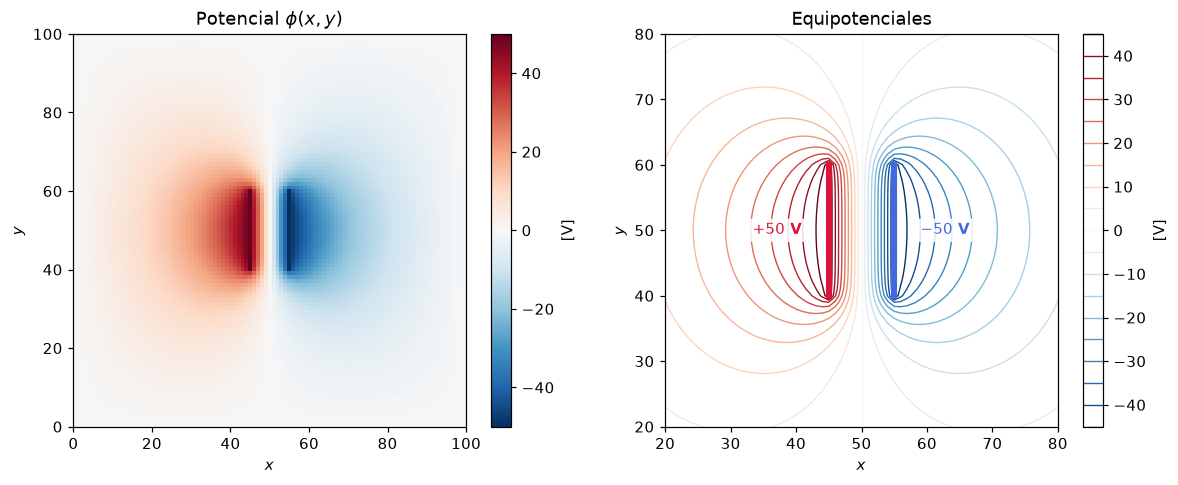

In [17]:
POSITIVA = "crimson"
NEGATIVA = "royalblue"


def dibujar_placas(ax, separacion_etiqueta=4.0):
    """Dibuja las dos placas marcando cual es la positiva."""
    ax.plot([eje[izq], eje[izq]], [eje[abajo], eje[arriba]], color=POSITIVA, lw=4)
    ax.plot([eje[der], eje[der]], [eje[abajo], eje[arriba]], color=NEGATIVA, lw=4)

    altura_media = 0.5*(eje[abajo] + eje[arriba])
    fondo = dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.85)
    ax.text(eje[izq] - separacion_etiqueta, altura_media, f"$+{voltaje_placa:.0f}$ V",
            color=POSITIVA, ha="right", va="center", fontsize=10, weight="bold", bbox=fondo)
    ax.text(eje[der] + separacion_etiqueta, altura_media, f"$-{voltaje_placa:.0f}$ V",
            color=NEGATIVA, ha="left", va="center", fontsize=10, weight="bold", bbox=fondo)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

imagen = axes[0].imshow(phi.T, origin="lower", extent=[0, lado_caja, 0, lado_caja],
                       cmap="RdBu_r", vmin=-voltaje_placa, vmax=voltaje_placa)
axes[0].set_title(r"Potencial $\phi(x,y)$")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
fig.colorbar(imagen, ax=axes[0], label="[V]")

contours = axes[1].contour(eje, eje, phi.T, levels=np.linspace(-45, 45, 19),
                           cmap="RdBu_r", linewidths=0.9)
dibujar_placas(axes[1])
axes[1].set_xlim(20, 80)
axes[1].set_ylim(20, 80)
axes[1].set_aspect("equal")
axes[1].set_title("Equipotenciales")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")
fig.colorbar(contours, ax=axes[1], label="[V]")

fig.tight_layout()
plt.show()

Entre las placas las equipotenciales son rectas verticales igualmente espaciadas, la firma de un campo
uniforme; hacia los extremos se curvan y más allá se cierran alrededor de cada placa como un dipolo.

## 3.1 Campo eléctrico

El campo es **menos el gradiente del potencial**:

$$\vec{E}=-\nabla\phi=-\frac{\partial\phi}{\partial x}\hat{\imath}-\frac{\partial\phi}{\partial y}\hat{\jmath},$$

y esas dos derivadas se evalúan otra vez por diferencias finitas. Cuál de las dos fórmulas va en cada
nodo depende de dónde esté el nodo en la malla. La lateral de tres puntos sale de eliminar el término
en $\Delta^2$ entre los desarrollos de $\phi_1$ y $\phi_2$, así que es de segundo orden igual que la
centrada; la de dos puntos sería de primer orden y se descarta.

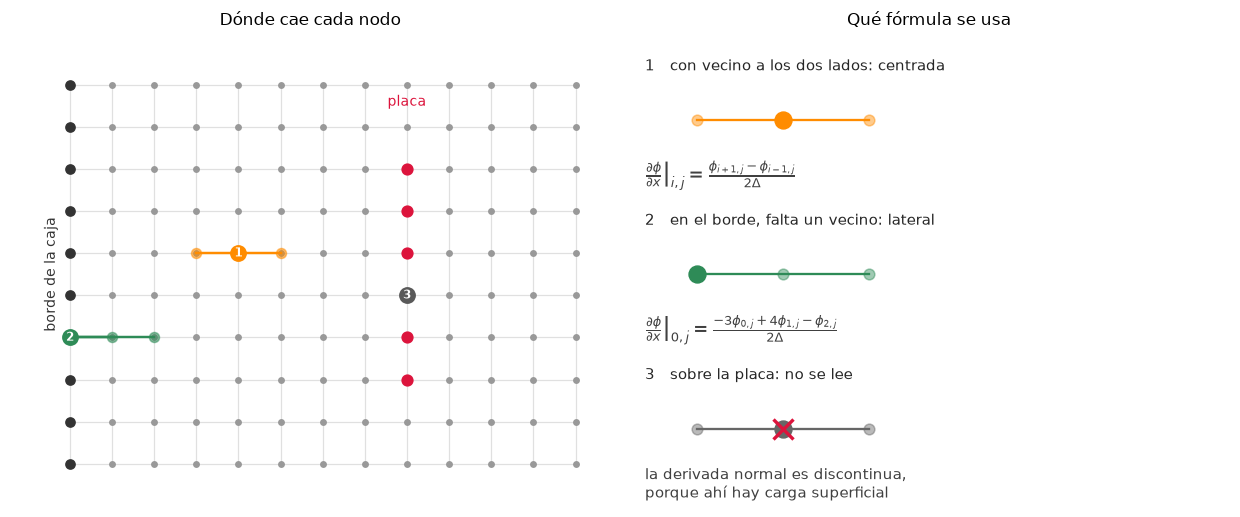

En $y$ es lo mismo cambiando el índice: los extremos son ahora la primera y la última columna.

In [18]:
def derivada_x(campo, paso):
    """d/dx por diferencias finitas de tres puntos: centrada dentro, lateral en los extremos."""
    n_filas, n_columnas = campo.shape
    resultado = np.zeros((n_filas, n_columnas))
    for i in range(n_filas):
        for j in range(n_columnas):
            if i == 0:
                resultado[i, j] = (-3.0*campo[0, j] + 4.0*campo[1, j] - campo[2, j])/(2.0*paso)
            elif i == n_filas - 1:
                resultado[i, j] = (3.0*campo[i, j] - 4.0*campo[i-1, j] + campo[i-2, j])/(2.0*paso)
            else:
                resultado[i, j] = (campo[i+1, j] - campo[i-1, j])/(2.0*paso)
    return resultado


def derivada_y(campo, paso):
    """d/dy por diferencias finitas de tres puntos: centrada dentro, lateral en los extremos."""
    n_filas, n_columnas = campo.shape
    resultado = np.zeros((n_filas, n_columnas))
    for i in range(n_filas):
        for j in range(n_columnas):
            if j == 0:
                resultado[i, j] = (-3.0*campo[i, 0] + 4.0*campo[i, 1] - campo[i, 2])/(2.0*paso)
            elif j == n_columnas - 1:
                resultado[i, j] = (3.0*campo[i, j] - 4.0*campo[i, j-1] + campo[i, j-2])/(2.0*paso)
            else:
                resultado[i, j] = (campo[i, j+1] - campo[i, j-1])/(2.0*paso)
    return resultado


def campo_electrico(potencial, paso):
    """Campo electrico como menos el gradiente del potencial."""
    return -derivada_x(potencial, paso), -derivada_y(potencial, paso)


def magnitud(comp_x, comp_y):
    """Norma euclidiana de un campo vectorial dado por sus componentes."""
    return np.sqrt(comp_x*comp_x + comp_y*comp_y)


prueba = np.zeros((len(eje), 3))
for i in range(len(eje)):
    for j in range(3):
        prueba[i, j] = np.sin(2.0*np.pi*eje[i]/lado_caja)
comprobacion = derivada_x(prueba, dx)
exacto = (2.0*np.pi/lado_caja)*np.cos(2.0*np.pi*eje/lado_caja)
print(f"prueba de la derivada sobre sin(2 pi x / L): error maximo "
      f"{np.abs(comprobacion[:, 1] - exacto).max():.2e}")

campo_x, campo_y = campo_electrico(phi, dx)
campo_magnitud = magnitud(campo_x, campo_y)
campo_ideal = 2.0*voltaje_placa/separacion_placas
medio = len(eje)//2

print(f"campo ideal DeltaV/d        = {campo_ideal:.3f} V/m")
print(f"|E| en el centro del hueco  = {campo_magnitud[medio, medio]:.3f} V/m "
      f"({100*(campo_magnitud[medio, medio]/campo_ideal - 1):+.2f} %)")
print(f"|E| en el extremo de placa  = {campo_magnitud[medio, arriba]:.3f} V/m")
print(f"|E| a 10 nodos por fuera    = {campo_magnitud[der + 10, medio]:.3f} V/m")

prueba de la derivada sobre sin(2 pi x / L): error maximo 8.26e-05
campo ideal DeltaV/d        = 10.000 V/m
|E| en el centro del hueco  = 9.987 V/m (-0.13 %)
|E| en el extremo de placa  = 8.044 V/m
|E| a 10 nodos por fuera    = 1.656 V/m


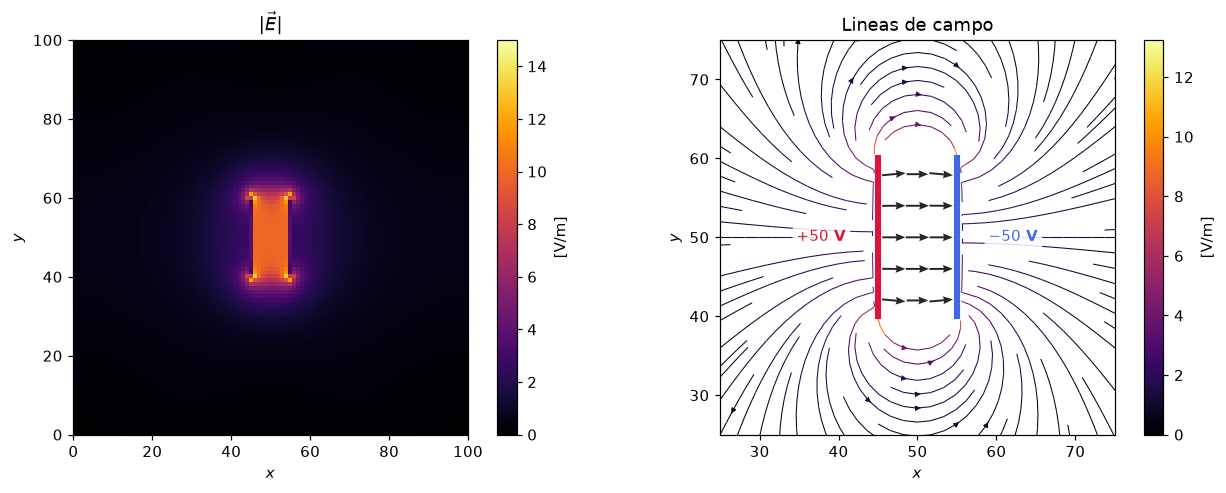

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

imagen = axes[0].imshow(campo_magnitud.T, origin="lower", extent=[0, lado_caja, 0, lado_caja],
                       cmap="inferno", vmax=1.5*campo_ideal)
axes[0].set_title(r"$|\vec{E}|$")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
fig.colorbar(imagen, ax=axes[0], label="[V/m]")

stream = axes[1].streamplot(eje, eje, campo_x.T, campo_y.T, color=campo_magnitud.T,
                            cmap="inferno", density=1.9, linewidth=0.7, arrowsize=0.7)

flecha_x, flecha_y, flecha_u, flecha_v = [], [], [], []
for i in range(izq + 2, der, 3):
    for j in range(abajo + 2, arriba, 4):
        flecha_x.append(eje[i])
        flecha_y.append(eje[j])
        flecha_u.append(campo_x[i, j])
        flecha_v.append(campo_y[i, j])
axes[1].quiver(flecha_x, flecha_y, flecha_u, flecha_v, color="0.15",
               scale=170, width=0.005, headwidth=4, pivot="mid")

dibujar_placas(axes[1])
axes[1].set_xlim(25, 75)
axes[1].set_ylim(25, 75)
axes[1].set_aspect("equal")
axes[1].set_title("Lineas de campo")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")
fig.colorbar(stream.lines, ax=axes[1], label="[V/m]")

fig.tight_layout()
plt.show()

Las líneas salen perpendiculares de la placa positiva y entran perpendiculares a la negativa, como
exige que un conductor sea equipotencial. En el hueco van paralelas y uniformemente densas; en los
extremos se abomban y algunas escapan hasta la caja.

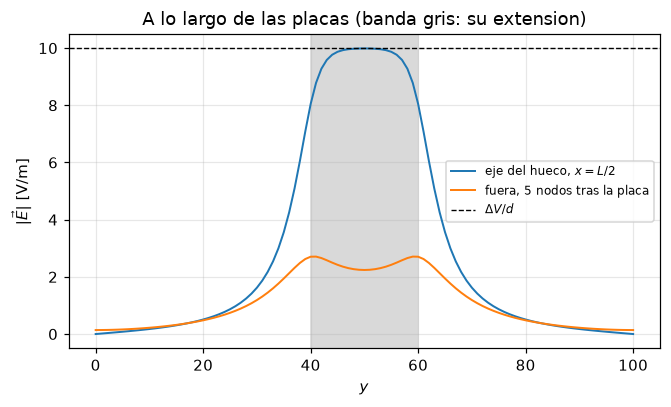

In [20]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))

ax.plot(eje, campo_magnitud[medio, :], lw=1.3, label="eje del hueco, $x=L/2$")
ax.plot(eje, campo_magnitud[der+5, :], lw=1.3, label="fuera, 5 nodos tras la placa")
ax.axhline(campo_ideal, color="k", ls="--", lw=0.9, label=r"$\Delta V/d$")
ax.axvspan(eje[abajo], eje[arriba], color="0.85", zorder=0)
ax.set_xlabel("$y$")
ax.set_ylabel(r"$|\vec{E}|$ [V/m]")
ax.set_title("A lo largo de las placas (banda gris: su extension)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

En el hueco el campo reproduce $\Delta V/d$ dentro del $0.2\ \%$, cae un $20\ \%$ a pocos nodos del
extremo de la placa y afuera decae sin llegar a anularse. La zona de transición mide del orden de la
separación $d$, no de la longitud $\ell$, así que lo que decide el peso de los bordes es la razón
$\ell/d$.

---

## Referencias

- R. Landau, M. J. Páez y C. Bordeianu, *Computational Physics*, 3.ª ed., Wiley-VCH (2015), cap. 19.
- W. Press *et al.*, *Numerical Recipes*, 3.ª ed., Cambridge (2007), cap. 20, de donde salen
  $\rho_{\text{Jacobi}}=\cos(\pi/N)$ y $\omega_{\text{opt}}=2/[1+\sin(\pi/N)]$.
- J. D. Jackson, *Classical Electrodynamics*, 3.ª ed., Wiley (1999), cap. 2.
- Material del curso: `Sesiones/PDE/1_PDE_theory.ipynb`,
  `2.1_Finite_Differece_Method_FDM.ipynb` y `capacitor.py`.